# Data Cleaning & Feature Engineering Pipeline
**Pharmacy2U | DE-SynPUF Part D | Data & AI Hackathon**

Produces the feature-rich dataset (`full_df_with_msr.parquet`) consumed by the modelling notebook.

| # | Section | What happens |
|---|---------|-------------|
| 0 | Setup | Imports, file paths, column lists, constants |
| 1 | Load Raw Data | Read PDE and beneficiary CSVs; data dictionary |
| 2 | Clean PDE | Date parsing, zero-supply removal, minimum-fill filter |
| 3 | Merge PDE + Beneficiary | Inner join on patient ID; drop leakage columns |
| 4 | Feature Engineering | Age, comorbidities, cost ratios, categorical encoding |
| 5 | NDC Drug Metadata Join | Extract manufacturer/ingredient from NDC-11 codes |
| 6 | PDC Scores | Proportion of Days Covered per patient-ingredient |
| 7 | Final Export | Save to Parquet for downstream modelling |


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
## 0. Setup

Imports, file paths (Google Drive), column selection lists (`PDE_COLS`, `DISEASE_COLS`), and global constants (`GRACE_DAYS`, `LEAKAGE_COLS`).


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 200)

# ── File paths (Google Drive) ─────────────────────────────────────────────────
PDE_PATH  = '/content/drive/MyDrive/pharma2u/datasets/DE1_0_2008_to_2010_Prescription_Drug_Events_Sample_1.csv'
BENE_PATH = '/content/drive/MyDrive/pharma2u/datasets/DE1_0_2010_Beneficiary_Summary_File_Sample_1.csv'

# ── Columns & dtypes ─────────────────────────────────────────────────────────
PDE_COLS = ['DESYNPUF_ID', 'SRVC_DT', 'PROD_SRVC_ID',
            'QTY_DSPNSD_NUM', 'DAYS_SUPLY_NUM', 'PTNT_PAY_AMT', 'TOT_RX_CST_AMT']

PDE_DTYPES = {
    'DESYNPUF_ID'   : 'category',
    'PROD_SRVC_ID'  : 'object',
    'QTY_DSPNSD_NUM': 'float32',
    'DAYS_SUPLY_NUM': 'float32',
    'PTNT_PAY_AMT'  : 'float32',
    'TOT_RX_CST_AMT': 'float32',
}

# SP_ disease columns (1 = yes, 2 = no in raw data)
DISEASE_COLS = [
    'SP_ALZHDMTA', 'SP_CHF', 'SP_CHRNKIDN', 'SP_CNCR', 'SP_COPD',
    'SP_DEPRESSN', 'SP_DIABETES', 'SP_ISCHMCHT', 'SP_OSTEOPRS',
    'SP_RA_OA', 'SP_STRKETIA'
]

# Columns from beneficiary file that would cause data leakage
LEAKAGE_COLS = [
    'MEDREIMB_IP', 'BENRES_IP', 'PPPYMT_IP',
    'MEDREIMB_OP', 'BENRES_OP', 'PPPYMT_OP',
    'MEDREIMB_CAR', 'BENRES_CAR', 'PPPYMT_CAR',
    'BENE_HI_CVRAGE_TOT_MONS', 'BENE_SMI_CVRAGE_TOT_MONS',
    'BENE_HMO_CVRAGE_TOT_MONS', 'PLAN_CVRG_MOS_NUM',
]

print('Config ready!!!')

Config ready!!!


---
## 1. Load Raw Data

**Data dictionary**

| Column | Source | Description |
|---|---|---|
| `DESYNPUF_ID` | Both | Pseudonymised patient ID |
| `SRVC_DT` | PDE | Prescription dispense date (YYYYMMDD int) |
| `PROD_SRVC_ID` | PDE | NDC-11 drug code |
| `QTY_DSPNSD_NUM` | PDE | Units dispensed |
| `DAYS_SUPLY_NUM` | PDE | Days of supply |
| `PTNT_PAY_AMT` | PDE | Patient out-of-pocket amount |
| `TOT_RX_CST_AMT` | PDE | Total drug cost |
| `BENE_BIRTH_DT` | Bene | Date of birth |
| `BENE_DEATH_DT` | Bene | Date of death (NaN = alive / unknown) |
| `BENE_SEX_IDENT_CD` | Bene | 1 = Male, 2 = Female |
| `BENE_RACE_CD` | Bene | 1=White, 2=Black, 3=Other, 4=Asian, 5=Hispanic, 6=Native Am. |
| `SP_*` | Bene | Chronic condition flags (1=Yes, 2=No in raw) |

In [3]:
# ── Option A: load from Google Drive (full dataset) ───────────────────────────
pde  = pd.read_csv(PDE_PATH,  usecols=PDE_COLS, dtype=PDE_DTYPES, low_memory=False)
bene = pd.read_csv(BENE_PATH, low_memory=False)

print(f'PDE  shape : {pde.shape}')
print(f'Bene shape : {bene.shape}')

PDE  shape : (5552421, 7)
Bene shape : (112754, 32)


In [ ]:
# ── Option B: manual upload (fallback for testing) ────────────────────────────
# Uncomment if not using Drive

# from google.colab import files
# import io
# uploaded = files.upload()
# filename = list(uploaded.keys())[0]
# pde = pd.read_csv(io.BytesIO(uploaded[filename]),
#                   usecols=PDE_COLS, dtype=PDE_DTYPES)
# print(f'Uploaded {filename}: {pde.shape}')

In [4]:
# ── Quick audit ───────────────────────────────────────────────────────────────
def audit(df, name):
    print(f'\n{"="*10} {name} {"="*10}')
    print(f'  Shape   : {df.shape}')
    print(f'  dtypes  :\n{df.dtypes.to_string()}')
    missing = df.isnull().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    if len(missing):
        print(f'  Missing :\n{missing.to_string()}')
    else:
        print('  Missing : none')

audit(pde,  'PDE')
audit(bene, 'Beneficiary')


========== PDE ==========
  Shape   : (5552421, 7)
  dtypes  :
DESYNPUF_ID       category
SRVC_DT              int64
PROD_SRVC_ID        object
QTY_DSPNSD_NUM     float32
DAYS_SUPLY_NUM     float32
PTNT_PAY_AMT       float32
TOT_RX_CST_AMT     float32
  Missing : none

========== Beneficiary ==========
  Shape   : (112754, 32)
  dtypes  :
DESYNPUF_ID                  object
BENE_BIRTH_DT                 int64
BENE_DEATH_DT               float64
BENE_SEX_IDENT_CD             int64
BENE_RACE_CD                  int64
BENE_ESRD_IND                object
SP_STATE_CODE                 int64
BENE_COUNTY_CD                int64
BENE_HI_CVRAGE_TOT_MONS       int64
BENE_SMI_CVRAGE_TOT_MONS      int64
BENE_HMO_CVRAGE_TOT_MONS      int64
PLAN_CVRG_MOS_NUM             int64
SP_ALZHDMTA                   int64
SP_CHF                        int64
SP_CHRNKIDN                   int64
SP_CNCR                       int64
SP_COPD                       int64
SP_DEPRESSN                   int64
SP_DIABETE

---
## 2. Clean PDE

Standardise prescription drug event records before merging:

- Parse `SRVC_DT` from YYYYMMDD integer to `datetime`
- Drop rows missing patient ID or service date
- Remove invalid `PROD_SRVC_ID = 'OTHER'` entries
- Flag and impute zero/missing `DAYS_SUPLY_NUM`; drop values outside 1–364 days
- Keep only patients with **≥ 2** prescription records (minimum needed to label a refill pair)
- Sort chronologically by patient and date


In [5]:
pde_clean = pde.copy()
n0 = len(pde_clean)

# ── Parse date ────────────────────────────────────────────────────────────────
pde_clean['SRVC_DT'] = pd.to_datetime(
    pde_clean['SRVC_DT'].astype(str), format='%Y%m%d', errors='coerce'
)

# ── Drop records missing critical identifiers ─────────────────────────────────
pde_clean = pde_clean.dropna(subset=['DESYNPUF_ID', 'SRVC_DT'])
print(f'After dropping null ID/date : {n0:,} -> {len(pde_clean):,}')

# ── Remove 'OTHER' drug codes ─────────────────────────────────────────────────
pde_clean = pde_clean[pde_clean['PROD_SRVC_ID'] != 'OTHER']
print(f'After removing OTHER NDCs  : {len(pde_clean):,}')

# ── Days supply: flag missing, impute with median, remove invalid ─────────────
median_supply = pde_clean['DAYS_SUPLY_NUM'].median()
pde_clean['days_supply_missing_flag'] = pde_clean['DAYS_SUPLY_NUM'].isnull().astype(int)
pde_clean['DAYS_SUPLY_NUM'] = pde_clean['DAYS_SUPLY_NUM'].fillna(median_supply)
pde_clean = pde_clean[
    pde_clean['DAYS_SUPLY_NUM'].between(1, 364, inclusive='both')
]
print(f'After days-supply filter   : {len(pde_clean):,}')

# ── Keep only patients with >= 2 prescription records ─────────────────────────
counts = pde_clean['DESYNPUF_ID'].value_counts()
valid_ids = counts[counts >= 2].index
pde_clean = pde_clean[pde_clean['DESYNPUF_ID'].isin(valid_ids)]
print(f'After >=2 records filter   : {len(pde_clean):,}')

# ── Sort chronologically ──────────────────────────────────────────────────────
pde_clean = pde_clean.sort_values(['DESYNPUF_ID', 'SRVC_DT']).reset_index(drop=True)

print(f'\nPDE cleaned: {n0:,} → {len(pde_clean):,} rows ({(1 - len(pde_clean)/n0)*100:.1f}% dropped)')

After dropping null ID/date : 5,552,421 -> 5,552,421
After removing OTHER NDCs  : 5,552,398
After days-supply filter   : 5,434,672
After >=2 records filter   : 5,429,311

PDE cleaned: 5,552,421 → 5,429,311 rows (2.2% dropped)


---
## 3. Merge PDE + Beneficiary

Join cleaned prescription records to the beneficiary summary on `DESYNPUF_ID`.

- Drop annual reimbursement/coverage totals (`LEAKAGE_COLS`) — these are year-level aggregates that would leak future utilisation into per-claim features
- Parse `BENE_BIRTH_DT` and `BENE_DEATH_DT` to `datetime`
- Set `DESYNPUF_ID` as the index
- Remove any patients who end up with only one prescription after the join


In [6]:
# ── Merge on patient ID ───────────────────────────────────────────────────────
merged_df = pd.merge(pde_clean, bene, on='DESYNPUF_ID', how='inner')
print(f'After merge: {len(merged_df):,} rows | {merged_df["DESYNPUF_ID"].nunique():,} patients')

# ── Drop leakage columns ──────────────────────────────────────────────────────
# These reimbursement/coverage totals are annual aggregates — using them
# would leak future information into per-claim features.
cols_to_drop = [c for c in LEAKAGE_COLS if c in merged_df.columns]
merged_df = merged_df.drop(columns=cols_to_drop)
print(f'Dropped {len(cols_to_drop)} leakage columns: {cols_to_drop}')

# ── Parse date columns ────────────────────────────────────────────────────────
for col, fmt in [('BENE_BIRTH_DT', '%Y%m%d'), ('BENE_DEATH_DT', '%Y%m%d')]:
    merged_df[col] = pd.to_datetime(
        merged_df[col].astype(str).str.split('.').str[0],  # strip .0 from float
        format=fmt, errors='coerce'
    )

# ── Set patient ID as index ───────────────────────────────────────────────────
merged_df = merged_df.set_index('DESYNPUF_ID')

# ── Remove patients with only a single prescription after merge ───────────────
single_entry_ids = merged_df.index.value_counts()
single_entry_ids = single_entry_ids[single_entry_ids == 1].index
merged_df = merged_df[~merged_df.index.isin(single_entry_ids)]
print(f'Removed {len(single_entry_ids):,} single-prescription patients')
print(f'Final: {len(merged_df):,} rows | {merged_df.index.nunique():,} patients')

merged_df.head(3)

After merge: 5,373,237 rows | 92,118 patients
Dropped 13 leakage columns: ['MEDREIMB_IP', 'BENRES_IP', 'PPPYMT_IP', 'MEDREIMB_OP', 'BENRES_OP', 'PPPYMT_OP', 'MEDREIMB_CAR', 'BENRES_CAR', 'PPPYMT_CAR', 'BENE_HI_CVRAGE_TOT_MONS', 'BENE_SMI_CVRAGE_TOT_MONS', 'BENE_HMO_CVRAGE_TOT_MONS', 'PLAN_CVRG_MOS_NUM']
Removed 0 single-prescription patients
Final: 5,373,237 rows | 92,118 patients


,SRVC_DT,PROD_SRVC_ID,QTY_DSPNSD_NUM,DAYS_SUPLY_NUM,PTNT_PAY_AMT,TOT_RX_CST_AMT,days_supply_missing_flag,BENE_BIRTH_DT,BENE_DEATH_DT,BENE_SEX_IDENT_CD,BENE_RACE_CD,BENE_ESRD_IND,SP_STATE_CODE,BENE_COUNTY_CD,SP_ALZHDMTA,SP_CHF,SP_CHRNKIDN,SP_CNCR,SP_COPD,SP_DEPRESSN,SP_DIABETES,SP_ISCHMCHT,SP_OSTEOPRS,SP_RA_OA,SP_STRKETIA
DESYNPUF_ID,,,,,,,,,,,,,,,,,,,,,,,,,
00013D2EFD8E45D1,2008-01-03,00247037252,30.0,20.0,10.0,120.0,0,1923-05-01,NaT,1,1,0,26,950,2,1,2,2,2,2,2,2,1,2,2
00013D2EFD8E45D1,2008-01-05,00223039502,10.0,10.0,0.0,0.0,0,1923-05-01,NaT,1,1,0,26,950,2,1,2,2,2,2,2,2,1,2,2
00013D2EFD8E45D1,2008-01-09,00364724812,120.0,30.0,10.0,110.0,0,1923-05-01,NaT,1,1,0,26,950,2,1,2,2,2,2,2,2,1,2,2


---
## 4. Feature Engineering

Build all model-ready features. Every feature uses only information available **at or before the dispensing date** — no future leakage.

| Sub-section | Features created |
|-------------|------------------|
| **4a** Age | `Age` at prescription date |
| **4b** Death flag | `has_death_record` |
| **4c** Comorbidities | Disease flags, system groupings (`cat_heart`, `cat_kidney_metabolic`, etc.), `is_frail`, complexity proxies |
| **4d** Financials | `oop_ratio`, `insurance_benefit_amt`, log-transforms, `flag_high_financial_barrier` |
| **4e** Categoricals | Cast sex, race, state, county to `category` dtype |
| **4f** Summary stats | Descriptive statistics for review |


In [7]:
# ── 4a. Age at prescription date ─────────────────────────────────────────────
merged_df['Age'] = (merged_df['SRVC_DT'] - merged_df['BENE_BIRTH_DT']).dt.days // 365

# ── 4b. Death record flag ─────────────────────────────────────────────────────
merged_df['has_death_record'] = merged_df['BENE_DEATH_DT'].notna().astype(int)

print('Age range:', merged_df['Age'].min(), '–', merged_df['Age'].max())
print('Death records:', merged_df['has_death_record'].sum())

Age range: 24 – 102
Death records: 77783


In [8]:
# ── 4c. Comorbidity features ──────────────────────────────────────────────────
#
# Raw encoding: 1 = condition present, 2 = absent
# Recode 2 → 0 BEFORE converting to category to avoid FutureWarning.
# Keep disease cols as int (not category) so we can do arithmetic on them.

for col in DISEASE_COLS:
    if col in merged_df.columns:
        merged_df[col] = merged_df[col].replace(2, 0).astype('int8')

# Total comorbidity count
merged_df['comorbidity_count'] = merged_df[DISEASE_COLS].sum(axis=1)

# System-level groupings (any condition in group = 1)
merged_df['cat_heart']             = merged_df[['SP_CHF', 'SP_ISCHMCHT', 'SP_STRKETIA']].max(axis=1)
merged_df['cat_kidney_metabolic']  = merged_df[['SP_CHRNKIDN', 'SP_DIABETES']].max(axis=1)
merged_df['cat_neuro_mental']      = merged_df[['SP_ALZHDMTA', 'SP_DEPRESSN']].max(axis=1)
merged_df['cat_musculoskeletal']   = merged_df[['SP_OSTEOPRS', 'SP_RA_OA']].max(axis=1)

# Frailty proxy: 3+ concurrent conditions
merged_df['is_frail'] = (merged_df['comorbidity_count'] >= 3).astype('int8')

# Behavioural complication: depression + at least one physical condition
physical_cols = [c for c in DISEASE_COLS if c != 'SP_DEPRESSN']
merged_df['flag_behavioral_complication'] = (
    (merged_df['SP_DEPRESSN'] == 1) &
    (merged_df[physical_cols].sum(axis=1) > 0)
).astype('int8')

# Metabolic-renal-cardiac triad: diabetes + kidney disease + (CHF or IHD)
merged_df['flag_triad_risk'] = (
    (merged_df['SP_DIABETES']  == 1) &
    (merged_df['SP_CHRNKIDN']  == 1) &
    ((merged_df['SP_CHF'] == 1) | (merged_df['SP_ISCHMCHT'] == 1))
).astype('int8')

print('Comorbidity features created')
print(merged_df[['comorbidity_count','is_frail','flag_behavioral_complication','flag_triad_risk']].describe().round(3))

Comorbidity features created
       comorbidity_count     is_frail  flag_behavioral_complication  \
count        5373237.000  5373237.000                   5373237.000   
mean               2.248        0.409                         0.233   
std                2.142        0.492                         0.423   
min                0.000        0.000                         0.000   
25%                0.000        0.000                         0.000   
50%                2.000        0.000                         0.000   
75%                4.000        1.000                         0.000   
max               11.000        1.000                         1.000   

       flag_triad_risk  
count      5373237.000  
mean             0.118  
std              0.323  
min              0.000  
25%              0.000  
50%              0.000  
75%              0.000  
max              1.000  


In [9]:
# ── 4d. Financial features ────────────────────────────────────────────────────

# Out-of-pocket ratio: what fraction of total cost the patient pays
# Guard against zero-cost rows
merged_df['insurance_benefit_amt'] = (
    merged_df['TOT_RX_CST_AMT'] - merged_df['PTNT_PAY_AMT']
).clip(lower=0)

merged_df['oop_ratio'] = np.where(
    merged_df['TOT_RX_CST_AMT'] > 0,
    merged_df['PTNT_PAY_AMT'] / merged_df['TOT_RX_CST_AMT'],
    0.0
).clip(0, 1)

# Log-transforms to reduce right skew
merged_df['log_ptnt_pay'] = np.log1p(merged_df['PTNT_PAY_AMT'])
merged_df['log_tot_cst']  = np.log1p(merged_df['TOT_RX_CST_AMT'])

# High financial barrier: patient pays > 50% of drug cost
merged_df['flag_high_financial_barrier'] = (
    merged_df['oop_ratio'] > 0.5
).astype('int8')

print('Financial features created')
print(merged_df[['oop_ratio','insurance_benefit_amt','flag_high_financial_barrier']].describe().round(3))

Financial features created
         oop_ratio  insurance_benefit_amt  flag_high_financial_barrier
count  5373237.000            5373237.000                  5373237.000
mean         0.205                 52.600                        0.157
std          0.349                 89.736                        0.364
min          0.000                  0.000                        0.000
25%          0.000                 10.000                        0.000
50%          0.000                 20.000                        0.000
75%          0.273                 60.000                        0.000
max          1.000                570.000                        1.000


In [10]:
# ── 4e. Cast remaining categorical identifiers ─────────────────────────────────
# Only convert columns that genuinely exist and are used as categories (not arithmetic)

cat_cols = ['BENE_SEX_IDENT_CD', 'BENE_RACE_CD', 'BENE_ESRD_IND',
            'SP_STATE_CODE', 'BENE_COUNTY_CD']

for col in cat_cols:
    if col in merged_df.columns:
        merged_df[col] = merged_df[col].astype('category')

print('Final schema:')
print(merged_df.dtypes.to_string())
print(f'\nFinal shape: {merged_df.shape}')

Final schema:
SRVC_DT                         datetime64[ns]
PROD_SRVC_ID                            object
QTY_DSPNSD_NUM                         float32
DAYS_SUPLY_NUM                         float32
PTNT_PAY_AMT                           float32
TOT_RX_CST_AMT                         float32
days_supply_missing_flag                 int64
BENE_BIRTH_DT                   datetime64[ns]
BENE_DEATH_DT                   datetime64[ns]
BENE_SEX_IDENT_CD                     category
BENE_RACE_CD                          category
BENE_ESRD_IND                         category
SP_STATE_CODE                         category
BENE_COUNTY_CD                        category
SP_ALZHDMTA                               int8
SP_CHF                                    int8
SP_CHRNKIDN                               int8
SP_CNCR                                   int8
SP_COPD                                   int8
SP_DEPRESSN                               int8
SP_DIABETES                               int8

In [11]:
# ── 4f. Summary statistics ────────────────────────────────────────────────────
num_cols = merged_df.select_dtypes(include='number').columns
display(merged_df[num_cols].describe().round(3))

,QTY_DSPNSD_NUM,DAYS_SUPLY_NUM,PTNT_PAY_AMT,TOT_RX_CST_AMT,days_supply_missing_flag,SP_ALZHDMTA,SP_CHF,SP_CHRNKIDN,SP_CNCR,SP_COPD,SP_DEPRESSN,SP_DIABETES,SP_ISCHMCHT,SP_OSTEOPRS,SP_RA_OA,SP_STRKETIA,Age,has_death_record,comorbidity_count,cat_heart,cat_kidney_metabolic,cat_neuro_mental,cat_musculoskeletal,is_frail,flag_behavioral_complication,flag_triad_risk,insurance_benefit_amt,oop_ratio,log_ptnt_pay,log_tot_cst,flag_high_financial_barrier
count,5373237.000,5373237.000,5373237.000,5373237.000,5373237.0,5373237.000,5373237.000,5373237.000,5373237.000,5373237.000,5373237.000,5373237.000,5373237.000,5373237.000,5373237.000,5373237.000,5373237.000,5373237.000,5373237.000,5373237.000,5373237.000,5373237.000,5373237.000,5373237.000,5373237.000,5373237.000,5373237.000,5373237.000,5373237.000,5373237.000,5373237.000
mean,50.940,34.926,10.389,61.927,0.0,0.217,0.322,0.181,0.047,0.121,0.254,0.377,0.434,0.150,0.114,0.031,72.112,0.014,2.248,0.537,0.427,0.376,0.230,0.409,0.233,0.118,52.600,0.205,1.138,3.208,0.157
std,49.717,20.598,23.919,94.689,0.0,0.412,0.467,0.385,0.211,0.327,0.435,0.485,0.496,0.357,0.317,0.173,13.492,0.119,2.142,0.499,0.495,0.484,0.421,0.492,0.423,0.323,89.736,0.349,1.510,1.518,0.364
min,0.000,10.000,0.000,0.000,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,24.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,30.000,30.000,0.000,10.000,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,66.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,10.000,0.000,0.000,2.398,0.000
50%,30.000,30.000,0.000,20.000,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,73.000,0.000,2.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,20.000,0.000,0.000,3.045,0.000
75%,60.000,30.000,10.000,80.000,0.0,0.000,1.000,0.000,0.000,0.000,1.000,1.000,1.000,0.000,0.000,0.000,81.000,0.000,4.000,1.000,1.000,1.000,0.000,1.000,0.000,0.000,60.000,0.273,2.398,4.394,0.000
max,360.000,90.000,170.000,570.000,0.0,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,102.000,1.000,11.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,570.000,1.000,5.142,6.347,1.000


---
## 5. NDC Drug Metadata Join

NDC codes in DE-SynPUF are **synthetic** and will not resolve via RxNorm or openFDA. Instead, the 11-digit `PROD_SRVC_ID` is decomposed positionally into sub-fields:

| Characters | Field |
|------------|-------|
| 0–4 (5 chars) | `MANUFACTURER` (labeller code) |
| 5 (1 char) | `INGREDIENT` (product code — used as the drug grouping key) |
| 6 (1 char) | `STRENGTH` |
| 7 (1 char) | `DOSAGE` |
| 8 (1 char) | `ROUTE_ADMIN` |
| 9–10 (2 chars) | `PACKAGING` |

> **Note:** `INGREDIENT` (character 5) is used as the drug grouping key throughout — NDC-11 is unusable as a group key because the synthetic data randomises codes per event.


In [12]:
###########
# For PROD_SRVC_ID
######
# seperate ndc column
# separate ndc cols

merged_df['MANUFACTURER'] = merged_df['PROD_SRVC_ID'].apply(lambda x: x[:5])
merged_df['INGREDIENT'] = merged_df['PROD_SRVC_ID'].apply(lambda x: x[5])
merged_df['STRENGTH'] = merged_df['PROD_SRVC_ID'].apply(lambda x: x[6])
merged_df['DOSAGE'] = merged_df['PROD_SRVC_ID'].apply(lambda x: x[7])
merged_df['ROUTE_ADMIN'] = merged_df['PROD_SRVC_ID'].apply(lambda x: x[8])
merged_df['PACKAGING'] = merged_df['PROD_SRVC_ID'].apply(lambda x: x[9:])

In [18]:
# How many times does each patient fill each NDC?
fills_per_pt_ndc = (
    merged_df.reset_index()
    .groupby(['DESYNPUF_ID', 'PROD_SRVC_ID'])
    .size()
    .value_counts()
    .sort_index()
)
print("Fills per patient-NDC pair:")
print(fills_per_pt_ndc.head(10))

# vs fills per patient-INGREDIENT
fills_per_pt_ing = (
    merged_df.reset_index()
    .groupby(['DESYNPUF_ID', 'INGREDIENT'])
    .size()
    .value_counts()
    .sort_index()
)
print("\nFills per patient-INGREDIENT pair:")
print(fills_per_pt_ing.head(10))

Fills per patient-NDC pair:
1    5366846
2       3185
3          7
Name: count, dtype: int64

Fills per patient-INGREDIENT pair:
1     149331
2      93603
3      67989
4      50980
5      38633
6      28994
7      21936
8      16429
9      12299
10      9322
Name: count, dtype: int64


In [19]:
GRACE_DAYS = 14

work = merged_df.reset_index() if merged_df.index.name == 'DESYNPUF_ID' else merged_df.copy()
work = work.sort_values(['DESYNPUF_ID', 'INGREDIENT', 'SRVC_DT'])
work['RUN_OUT_DATE'] = work['SRVC_DT'] + pd.to_timedelta(work['DAYS_SUPLY_NUM'], unit='d')

# ── Vectorised shift (much faster than the Python loop) ──────────────────────
grp = work.groupby(['DESYNPUF_ID', 'INGREDIENT'], observed=True)

work['next_fill_dt'] = grp['SRVC_DT'].shift(-1)
work['gap_days']     = (work['next_fill_dt'] - work['RUN_OUT_DATE']).dt.days

# ── Label ─────────────────────────────────────────────────────────────────────
work['MISSES'] = 'NA'                                             # last fill / censored
work.loc[work['gap_days'].notna() & (work['gap_days'] <= GRACE_DAYS),  'MISSES'] = 'In time'
work.loc[work['gap_days'].notna() & (work['gap_days'] >  GRACE_DAYS),  'MISSES'] = 'Late'

# ── Diagnostics ───────────────────────────────────────────────────────────────
labelled_mask = work['MISSES'] != 'NA'
print("Gap days (labelled fills only):")
print(work.loc[labelled_mask, 'gap_days'].describe().round(1))
print()
print(work['MISSES'].value_counts(dropna=False))
print(f"\nLate rate: {(work['MISSES'] == 'Late').mean()*100:.1f}%")
print(f"Labelled fills: {labelled_mask.sum():,} / {len(work):,}  ({labelled_mask.mean()*100:.1f}%)")

# Write back
merged_df = work.set_index('DESYNPUF_ID')

Gap days (labelled fills only):
count    4795824.0
mean          17.3
std           99.1
min          -90.0
25%          -26.0
50%          -13.0
75%           17.0
max         1056.0
Name: gap_days, dtype: float64

MISSES
In time    3541244
Late       1254580
NA          577413
Name: count, dtype: int64

Late rate: 23.3%
Labelled fills: 4,795,824 / 5,373,237  (89.3%)


In [20]:
# Check the gap distribution before deciding on grace window
work['gap_days'] = (
    work.groupby(['DESYNPUF_ID', 'INGREDIENT'])['SRVC_DT'].shift(-1)
    - work['RUN_OUT_DATE']
).dt.days

print(work['gap_days'].describe().round(1))
print(f"\n% fills where gap > 0 (ran out before refilling): {(work['gap_days'] > 0).mean()*100:.1f}%")
print(f"% fills where gap > 14 (more than 2 week late)   : {(work['gap_days'] > 14).mean()*100:.1f}%")
print(f"% fills where gap < 0 (refilled early)           : {(work['gap_days'] < 0).mean()*100:.1f}%")

count    4795824.0
mean          17.3
std           99.1
min          -90.0
25%          -26.0
50%          -13.0
75%           17.0
max         1056.0
Name: gap_days, dtype: float64

% fills where gap > 0 (ran out before refilling): 30.7%
% fills where gap > 14 (more than 2 week late)   : 23.3%
% fills where gap < 0 (refilled early)           : 57.8%


In [21]:
# Load your NDC lookup table — replace path as needed
# Expected columns: index = DESYNPUF_ID (or a join key), plus drug metadata columns

# misses_df = pd.read_csv('misses_df.csv', index_col=0)

# full_df = merged_df.join(misses_df, how='inner')
# print(f'full_df shape after drug metadata join: {full_df.shape}')

# ── Fallback: use merged_df directly if no drug metadata available ─────────────
full_df = merged_df.copy()
print(f'full_df shape: {full_df.shape}')
full_df.head(3)

full_df shape: (5373237, 50)


,SRVC_DT,PROD_SRVC_ID,QTY_DSPNSD_NUM,DAYS_SUPLY_NUM,PTNT_PAY_AMT,TOT_RX_CST_AMT,days_supply_missing_flag,BENE_BIRTH_DT,BENE_DEATH_DT,BENE_SEX_IDENT_CD,BENE_RACE_CD,BENE_ESRD_IND,SP_STATE_CODE,BENE_COUNTY_CD,SP_ALZHDMTA,SP_CHF,SP_CHRNKIDN,SP_CNCR,SP_COPD,SP_DEPRESSN,SP_DIABETES,SP_ISCHMCHT,SP_OSTEOPRS,SP_RA_OA,SP_STRKETIA,Age,has_death_record,comorbidity_count,cat_heart,cat_kidney_metabolic,cat_neuro_mental,cat_musculoskeletal,is_frail,flag_behavioral_complication,flag_triad_risk,insurance_benefit_amt,oop_ratio,log_ptnt_pay,log_tot_cst,flag_high_financial_barrier,MANUFACTURER,INGREDIENT,STRENGTH,DOSAGE,ROUTE_ADMIN,PACKAGING,MISSES,RUN_OUT_DATE,next_fill_dt,gap_days
DESYNPUF_ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
00013D2EFD8E45D1,2008-01-03,00247037252,30.0,20.0,10.0,120.0,0,1923-05-01,NaT,1,1,0,26,950,0,1,0,0,0,0,0,0,1,0,0,84,0,2,1,0,0,1,0,0,0,110.0,0.083333,2.397895,4.795791,0,00247,0,3,7,2,52,In time,2008-01-23,2008-01-05,-18.0
00013D2EFD8E45D1,2008-01-05,00223039502,10.0,10.0,0.0,0.0,0,1923-05-01,NaT,1,1,0,26,950,0,1,0,0,0,0,0,0,1,0,0,84,0,2,1,0,0,1,0,0,0,0.0,0.000000,0.000000,0.000000,0,00223,0,3,9,5,02,In time,2008-01-15,2008-01-24,9.0
00013D2EFD8E45D1,2008-01-24,58016005300,30.0,30.0,70.0,70.0,0,1923-05-01,NaT,1,1,0,26,950,0,1,0,0,0,0,0,0,1,0,0,84,0,2,1,0,0,1,0,0,0,0.0,1.000000,4.262680,4.262680,1,58016,0,0,5,3,00,In time,2008-02-23,2008-01-24,-30.0


---
## 6. PDC (Proportion of Days Covered) Scores

Calculate medication adherence scores per patient-ingredient pair using the `pdcscore` library.

- **Measurement period:** first fill date → first fill + 365 days
- **Mortality adjustment:** end date capped at `BENE_DEATH_DT` where applicable (competing risk)
- Prescriptions dispensed > 14 days after recorded death are flagged for data quality review
- `is_adherent = 1` where `pdc_score ≥ 0.80` (standard pharmacy quality measure threshold)


In [22]:
!pip install pdcscore -q

In [23]:
# from pdcscore import pdcCalc

# ── Build measurement periods per patient-ingredient ─────────────────────────
# Start = first fill date, end = min(start + 365 days, death date)

measurement_periods = (
    full_df.reset_index()
    .groupby(['DESYNPUF_ID', 'INGREDIENT'])['SRVC_DT']
    .agg(msr_start_dt='min', msr_end_dt='max')
    .reset_index()
)

full_df_with_msr = pd.merge(
    full_df.reset_index(),
    measurement_periods,
    on=['DESYNPUF_ID', 'INGREDIENT'],
    how='left'
)

# Ensure datetime types
for col in ['SRVC_DT', 'msr_start_dt', 'msr_end_dt', 'BENE_DEATH_DT']:
    full_df_with_msr[col] = pd.to_datetime(full_df_with_msr[col])

# ── Adjust measurement end date for mortality (competing risk) ────────────────
full_df_with_msr['msr_end_dt_default'] = (
    full_df_with_msr['msr_start_dt'] + pd.Timedelta(days=365)
)

died_before_window = (
    full_df_with_msr['BENE_DEATH_DT'].notna() &
    (full_df_with_msr['BENE_DEATH_DT'] < full_df_with_msr['msr_end_dt_default'])
)
full_df_with_msr['msr_end_dt_adjusted'] = np.where(
    died_before_window,
    full_df_with_msr['BENE_DEATH_DT'],
    full_df_with_msr['msr_end_dt_default']
)
full_df_with_msr['msr_end_dt_adjusted'] = pd.to_datetime(
    full_df_with_msr['msr_end_dt_adjusted']
)

# ── Flag prescriptions > 14 days after recorded death (data quality check) ────
death_plus_grace = full_df_with_msr['BENE_DEATH_DT'] + pd.Timedelta(days=14)
full_df_with_msr['flag_prescription_too_late_after_death'] = (
    full_df_with_msr['BENE_DEATH_DT'].notna() &
    (full_df_with_msr['SRVC_DT'] > death_plus_grace)
).astype('int8')

print(f'Rows with msr periods: {len(full_df_with_msr):,}')
print(f'Post-death claims flagged: {full_df_with_msr["flag_prescription_too_late_after_death"].sum():,}')
full_df_with_msr[['SRVC_DT','msr_start_dt','msr_end_dt_adjusted',
                   'BENE_DEATH_DT','flag_prescription_too_late_after_death']].head(3)

Rows with msr periods: 5,373,237
Post-death claims flagged: 0


,SRVC_DT,msr_start_dt,msr_end_dt_adjusted,BENE_DEATH_DT,flag_prescription_too_late_after_death
0,2008-01-03,2008-01-03,2009-01-02,NaT,0
1,2008-01-05,2008-01-03,2009-01-02,NaT,0
2,2008-01-24,2008-01-03,2009-01-02,NaT,0


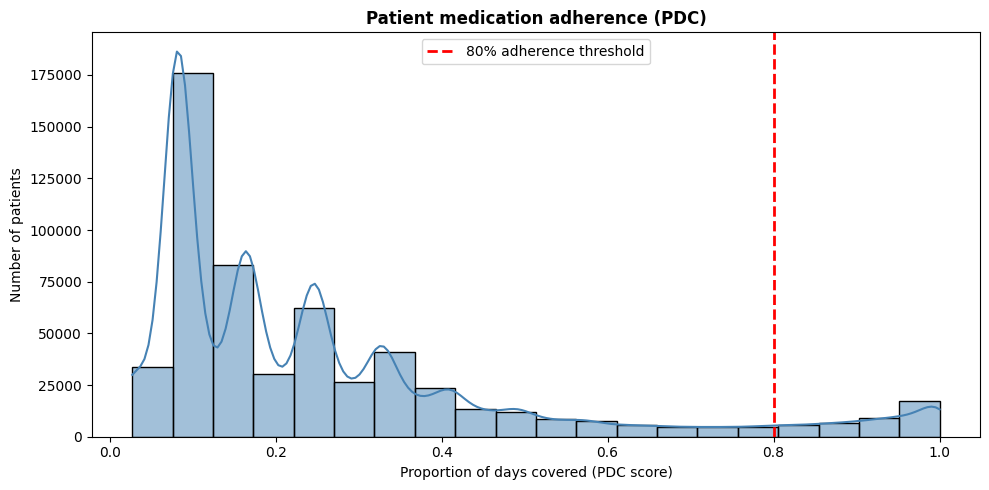

In [24]:
# ── Calculate PDC scores ──────────────────────────────────────────────────────
from pdcscore import pdcCalc

pdc_scores = pdcCalc(
    df=full_df_with_msr,
    patient_id_col='DESYNPUF_ID',
    drugname_col='INGREDIENT',
    filldate_col='SRVC_DT',
     supply_days_col='DAYS_SUPLY_NUM',
    msr_start_dt_col='msr_start_dt',
     msr_end_dt_col='msr_end_dt_adjusted',
     overlap_adjustment='True',
 )
pdc_scores_df = pdc_scores.calculate_pdc_scores()

# ── Merge PDC scores back ─────────────────────────────────────────────────────
final_df = pd.merge(
    full_df_with_msr,
    pdc_scores_df,
     on=['DESYNPUF_ID', 'INGREDIENT'],
     how='left'
 )
final_df['is_adherent'] = (final_df['pdc_score'] >= 0.80).astype('int8')

# ── Visualise PDC distribution ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(data=pdc_scores_df, x='pdc_score', bins=20, kde=True, color='steelblue', ax=ax)
ax.axvline(0.80, color='red', linestyle='--', lw=2, label='80% adherence threshold')
ax.set_title('Patient medication adherence (PDC)', fontweight='bold')
ax.set_xlabel('Proportion of days covered (PDC score)')
ax.set_ylabel('Number of patients')
ax.legend()
plt.tight_layout()
plt.show()



---
## 7. Final Export

Save the enriched dataset to Parquet for use in the modelling notebook.

| File | Contents |
|------|----------|
| `full_df_with_msr.parquet` | Full enriched dataset with measurement periods and PDC scores |
| `merged_df.parquet` | Intermediate merged dataset (before PDC calculation) |


In [25]:
# ── Save to parquet (much faster than CSV for downstream notebooks) ───────────
full_df_with_msr.to_parquet('full_df_with_msr.parquet', index=False)
merged_df.to_parquet('merged_df.parquet')

# ── Optional: download from Colab ─────────────────────────────────────────────
from google.colab import files
files.download('full_df_with_msr.parquet')

print('Saved:')
print(f'  merged_df         → {len(merged_df):,} rows × {merged_df.shape[1]} cols')
print(f'  full_df_with_msr  → {len(full_df_with_msr):,} rows × {full_df_with_msr.shape[1]} cols')
print('\nFinal columns:')
print(full_df_with_msr.columns.tolist())

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved:
  merged_df         → 5,373,237 rows × 50 cols
  full_df_with_msr  → 5,373,237 rows × 56 cols

Final columns:
['DESYNPUF_ID', 'SRVC_DT', 'PROD_SRVC_ID', 'QTY_DSPNSD_NUM', 'DAYS_SUPLY_NUM', 'PTNT_PAY_AMT', 'TOT_RX_CST_AMT', 'days_supply_missing_flag', 'BENE_BIRTH_DT', 'BENE_DEATH_DT', 'BENE_SEX_IDENT_CD', 'BENE_RACE_CD', 'BENE_ESRD_IND', 'SP_STATE_CODE', 'BENE_COUNTY_CD', 'SP_ALZHDMTA', 'SP_CHF', 'SP_CHRNKIDN', 'SP_CNCR', 'SP_COPD', 'SP_DEPRESSN', 'SP_DIABETES', 'SP_ISCHMCHT', 'SP_OSTEOPRS', 'SP_RA_OA', 'SP_STRKETIA', 'Age', 'has_death_record', 'comorbidity_count', 'cat_heart', 'cat_kidney_metabolic', 'cat_neuro_mental', 'cat_musculoskeletal', 'is_frail', 'flag_behavioral_complication', 'flag_triad_risk', 'insurance_benefit_amt', 'oop_ratio', 'log_ptnt_pay', 'log_tot_cst', 'flag_high_financial_barrier', 'MANUFACTURER', 'INGREDIENT', 'STRENGTH', 'DOSAGE', 'ROUTE_ADMIN', 'PACKAGING', 'MISSES', 'RUN_OUT_DATE', 'next_fill_dt', 'gap_days', 'msr_start_dt', 'msr_end_dt', 'msr_end_dt_def

In [ ]:
#files.download('full_df_with_msr.parquet')
